In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()
dataset=pd.read_excel('flood dataset.xlsx')

Saving flood dataset.xlsx to flood dataset.xlsx


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

/tmp/ipykernel_2766/1305145579.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Temp'])


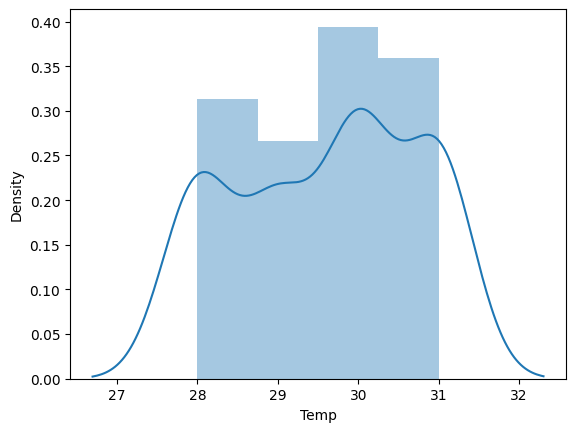

In [ ]:
sns.distplot(dataset['Temp'])
plt.show()

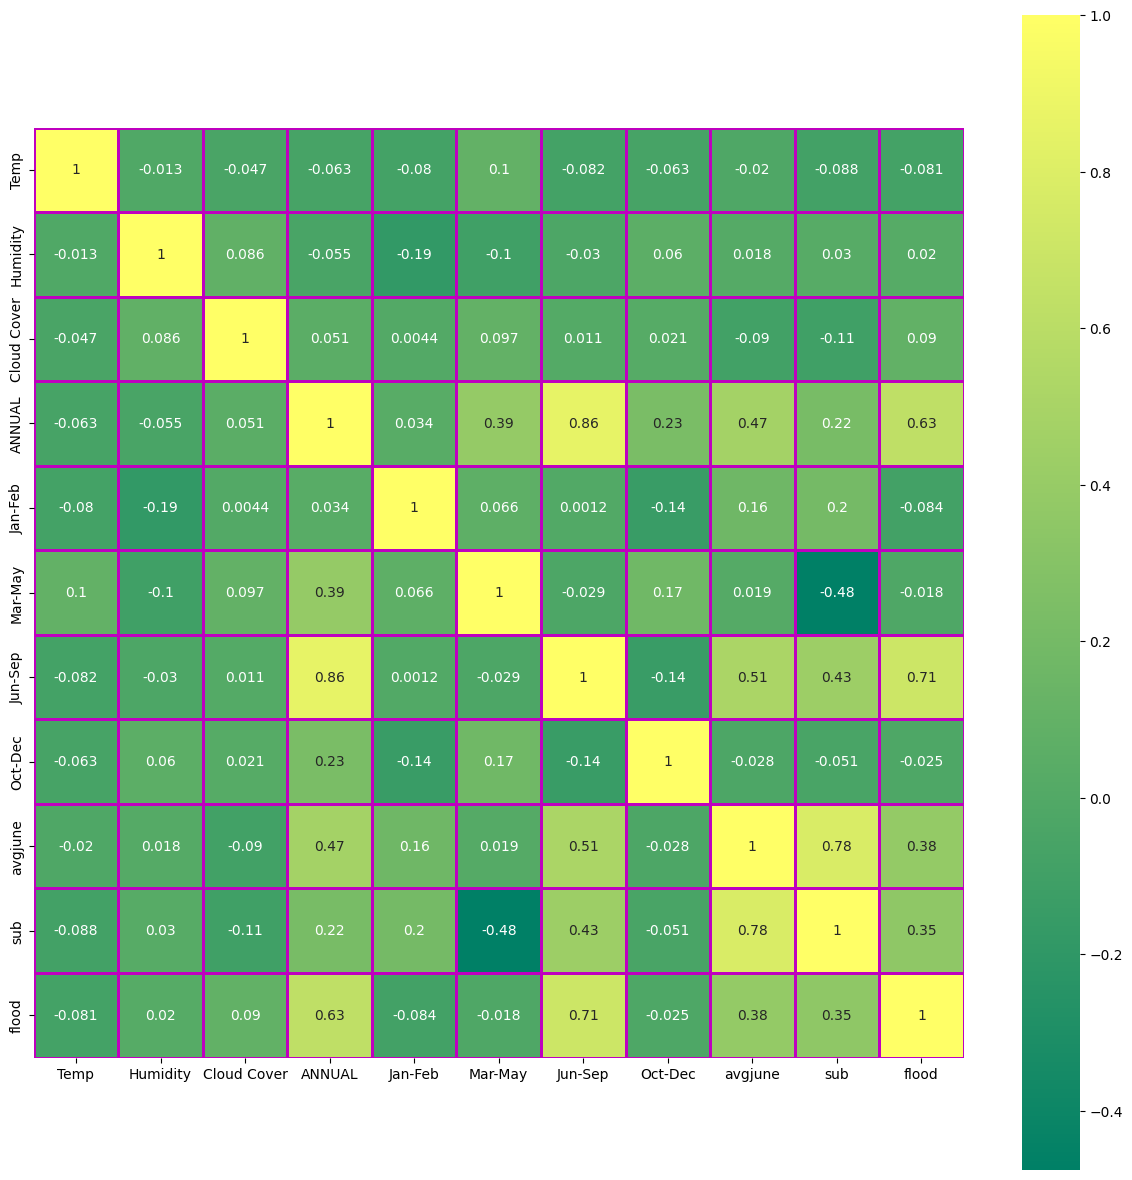

In [ ]:
fig=plt.gcf()
fig.set_size_inches(15,15)
fig=sns.heatmap(dataset.corr(),annot=True,cmap='summer',
                linewidth=1,linecolor='m',square=True,
                cbar_kws={"orientation":"vertical"},cbar=True)

In [ ]:
dataset.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [ ]:
dataset.describe()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100870,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547597,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666667,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033333,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833333,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066667,982.700000,1.000000


In [ ]:
dataset.isnull().any()

,0
Temp,False
Humidity,False
Cloud Cover,False
ANNUAL,False
Jan-Feb,False
Mar-May,False
Jun-Sep,False
Oct-Dec,False
avgjune,False
sub,False


In [ ]:
x=dataset.iloc[:,2:9].values
y=dataset.iloc[:,10].values

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=10)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.fit_transform(x_test)

In [ ]:
#Decision Tree
from sklearn import tree
from sklearn import ensemble
from sklearn import neighbors
import xgboost

dtree=tree.DecisionTreeClassifier()
Rf=ensemble.RandomForestClassifier()
knn=neighbors.KNeighborsClassifier()
xgb=xgboost.XGBClassifier()

dtree.fit(x_train,y_train)
Rf.fit(x_train,y_train)
knn.fit(x_train,y_train)
xgb.fit(x_train,y_train)

p1=dtree.predict(x_test)
p2=Rf.predict(x_test)
p3=knn.predict(x_test)
p4=xgb.predict(x_test)

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
def randomForest(X_train,X_test,y_train,y_test,n_estimators=100,random_state=42):
  print("\n===== Random forest model building=====")
  model=RandomForestClassifier(n_estimators=n_estimators,random_state=random_state)
  print(f"[INFO] RandomForestClassifier initialized with n_estimators={n_estimators}, random_state={random_state}")

  model.fit(X_train,y_train)
  print("[INFO] Model training completed")

  y_pred=model.predict(X_test)
  print("[INFO] Prediction completed on test data.")

  accuracy=accuracy_score(y_test,y_pred)
  cm=confusion_matrix(y_tst,y_pred)
  cr=classification_report(y_test,y_pred)

  print(f"\n [Result] Accuracy: {accuracy: 4f}")
  print("\n Confusion Matrix:")
  print(cm)
  print("\n Classification Report:\n")
  print(cr)
  return model,y_pred

In [ ]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
def KNN(X_train,X_test,y_train,y_test):
  print("\n===== KNN model building=====")
  model=KNeighborsClassifier(n_neighbors=5)

  model.fit(X_train,y_train)
  print("[INFO] KNN Model training completed")

  y_pred=model.predict(X_test)
  print("[INFO] Prediction completed on test data.")

  accuracy=accuracy_score(y_test,y_pred)
  cm=confusion_matrix(y_test,y_pred)
  cr=classification_report(y_test,y_pred)

  print(f"\n [Result] Accuracy: {accuracy: 4f}")
  print("\n Confusion Matrix:")
  print(cm)
  print("\n Classification Report:\n")
  print(cr)

  return model,y_pred

In [ ]:
#XGBOOST
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
def xgboost(X_train,X_test,y_train,y_test):
  print("\n===== XGBoost model building=====")
  model=GradientBoostingClassifier()
  model.fit(X_train,y_train)
  print("[INFO] XGBoost Model training completed")
  y_pred=model.predict(X_test)
  print("[INFO] Prediction completed on test data.")
  accuracy=accuracy_score(y_test,y_pred)
  cm=confusion_matrix(y_test,y_pred)
  cr=classification_report(y_test,y_pred)
  print(f"\n [Result] Accuracy: {accuracy: 4f}")
  print("\n Confusion Matrix:")
  print(cm)
  print("\n Classification Report:\n")
  print(cr)
  return model,y_pred

In [ ]:
from sklearn import metrics
print(metrics.accuracy_score(y_test,p1))
print(metrics.accuracy_score(y_test,p2))
print(metrics.accuracy_score(y_test,p3))
print(metrics.accuracy_score(y_test,p4))

0.9655172413793104
0.9655172413793104
0.9310344827586207
1.0


In [ ]:
print(confusion_matrix(y_test,p1))
print(confusion_matrix(y_test,p2))
print(confusion_matrix(y_test,p3))
print(confusion_matrix(y_test,p4))

[[25  1]
 [ 0  3]]
[[25  1]
 [ 0  3]]
[[25  1]
 [ 1  2]]
[[26  0]
 [ 0  3]]


In [ ]:
print(metrics.precision_score(y_test,p1))
print(metrics.precision_score(y_test,p2))
print(metrics.precision_score(y_test,p3))
print(metrics.precision_score(y_test,p4))

0.75
0.75
0.6666666666666666
1.0


In [ ]:
import joblib

In [ ]:
joblib.dump(dtree, 'decision_tree_model.pkl')
print('Decision Tree model saved as decision_tree_model.pkl')

Decision Tree model saved as decision_tree_model.pkl


In [ ]:
joblib.dump(Rf, 'random_forest_model.pkl')
print('Random Forest model saved as random_forest_model.pkl')

Random Forest model saved as random_forest_model.pkl


In [ ]:
joblib.dump(knn, 'knn_model.pkl')
print('KNN model saved as knn_model.pkl')

KNN model saved as knn_model.pkl


In [ ]:
joblib.dump(xgb, 'xgboost_model.pkl')
print('XGBoost model saved as xgboost_model.pkl')

XGBoost model saved as xgboost_model.pkl


### Flask Backend for XGBoost Model

To deploy your `xgboost_model.pkl` as a web service using Flask, you'll need two main files: `app.py` (your Flask application) and `requirements.txt` (listing the Python packages needed).

**File Structure:**

```
your_project/
├── app.py
├── xgboost_model.pkl
└── requirements.txt
```

In [ ]:
print(metrics.recall_score(y_test,p1))
print(metrics.recall_score(y_test,p2))
print(metrics.recall_score(y_test,p3))
print(metrics.recall_score(y_test,p4))

1.0
1.0
0.6666666666666666
1.0
